In [71]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

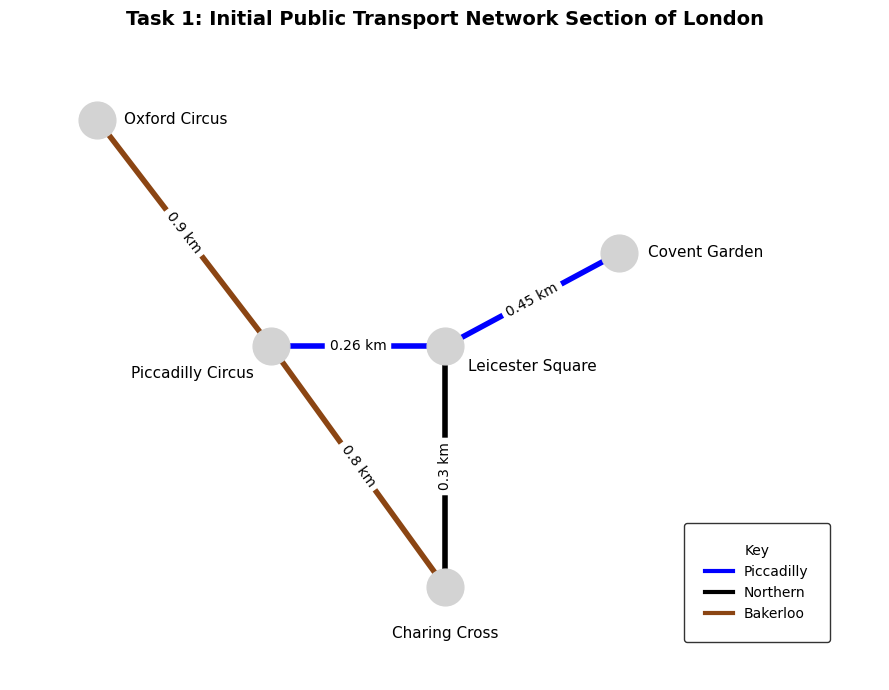

In [72]:
G1 = nx.Graph()

edges_t1 = [
    ('Oxford Circus', 'Piccadilly Circus', 0.9, 'saddlebrown'),
    ('Piccadilly Circus', 'Charing Cross', 0.8, 'saddlebrown'),
    ('Charing Cross', 'Leicester Square', 0.3, 'black'),
    ('Piccadilly Circus', 'Leicester Square', 0.26, 'blue'),
    ('Leicester Square', 'Covent Garden', 0.45, 'blue')
]

for u, v, w, c in edges_t1:
    G1.add_edge(u, v, weight=w, color=c)

pos_t1 = {
    'Oxford Circus': (1.0, 4.0),
    'Piccadilly Circus': (2.0, 2.3),
    'Charing Cross': (3.0, 0.5),
    'Leicester Square': (3.0, 2.3),
    'Covent Garden': (4.0, 3.0)
}

plt.figure(figsize=(9, 7))
colors1 = [G1[u][v]['color'] for u, v in G1.edges()]

nx.draw_networkx_nodes(G1, pos_t1, node_color='lightgray', node_size=700)
nx.draw_networkx_edges(G1, pos_t1, edge_color=colors1, width=4)

label_offsets = {
    'Oxford Circus': (1.45, 4.0),
    'Piccadilly Circus': (1.55, 2.1),
    'Charing Cross': (3.0, 0.15),
    'Leicester Square': (3.5, 2.15),
    'Covent Garden': (4.5, 3.0)
}
nx.draw_networkx_labels(G1, label_offsets, font_size=11)

edge_labels1 = nx.get_edge_attributes(G1, 'weight')
nx.draw_networkx_edge_labels(G1, pos_t1, edge_labels={k: f"{v} km" for k, v in edge_labels1.items()}, font_size=10)

for label, color in [('Piccadilly', 'blue'), ('Northern', 'black'), ('Bakerloo', 'saddlebrown')]:
    plt.plot([], [], color=color, label=label, linewidth=3)
    
plt.legend(title="Key", loc='lower right', bbox_to_anchor=(0.95, 0.05), borderpad=1.5, edgecolor='black', fontsize=10)

plt.title("Task 1: Initial Public Transport Network Section of London", fontsize=14, fontweight='bold', pad=20)
plt.xlim(0.5, 5.5)
plt.ylim(-0.2, 4.5)
plt.axis('off')
plt.tight_layout()
plt.show()

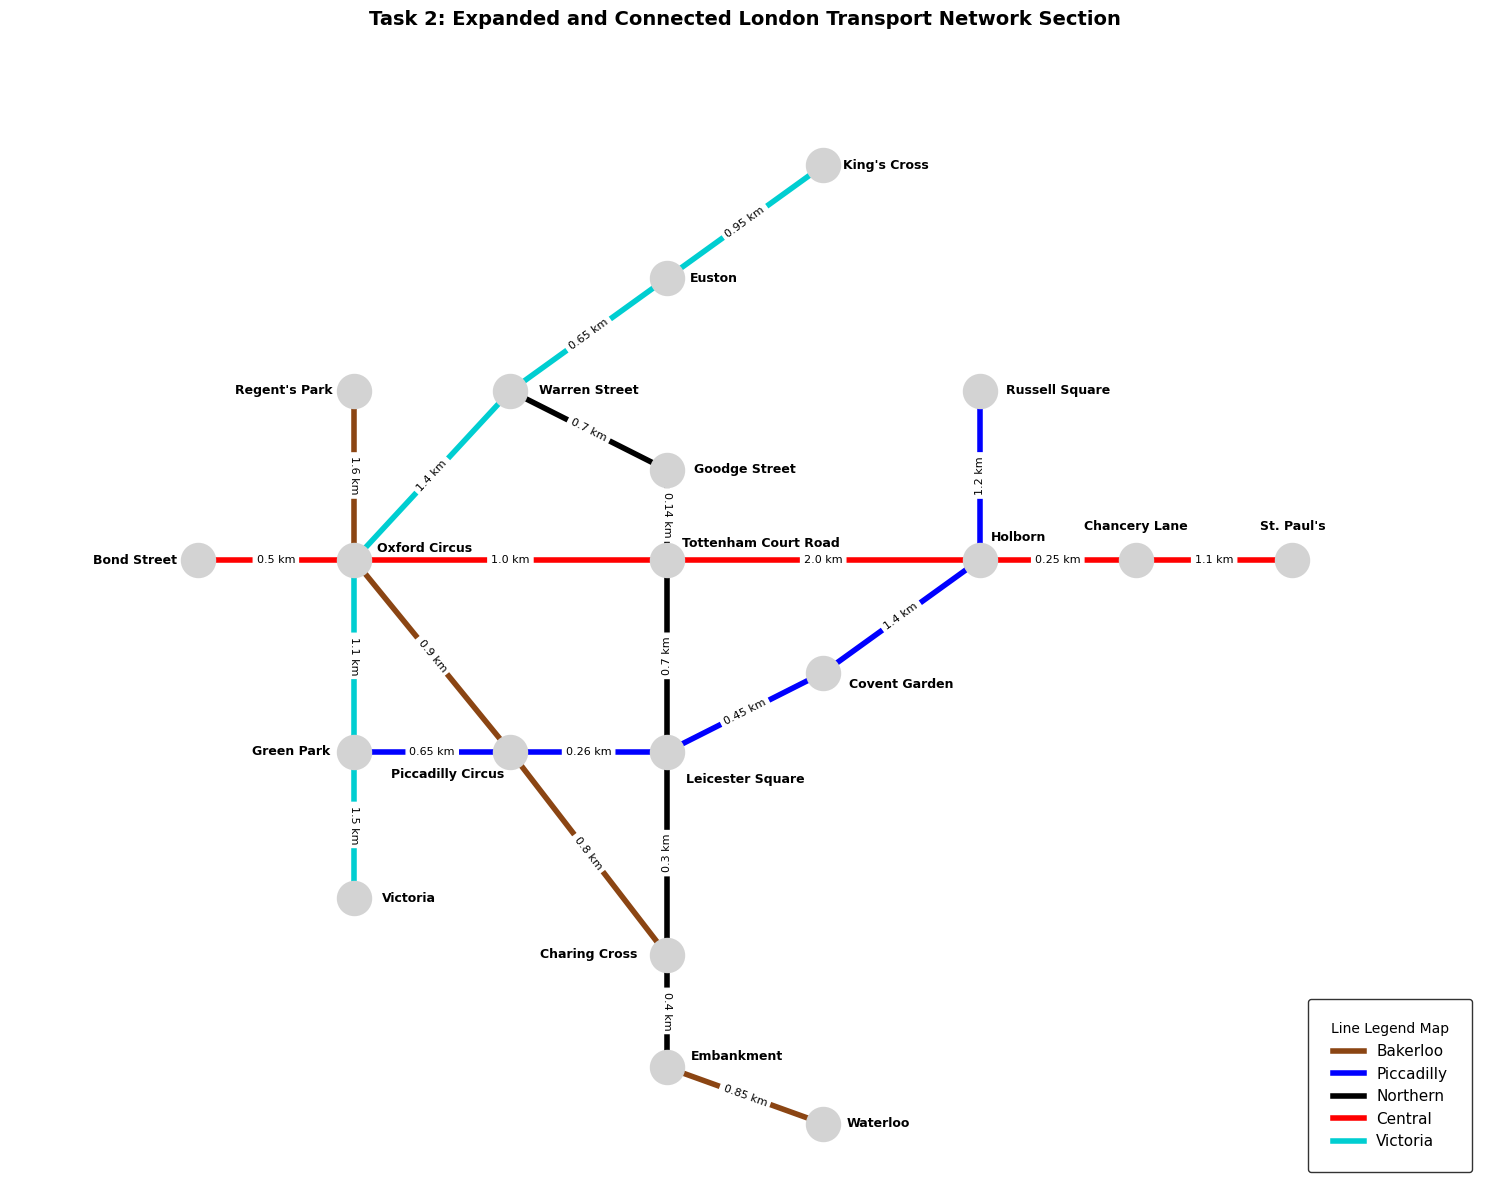

In [73]:
network_data = [
    ('Bakerloo', 'saddlebrown', [
        ("Regent's Park", 1.6), ('Oxford Circus', 0.9), ('Piccadilly Circus', 0.8), 
        ('Charing Cross', 0.2), ('Embankment', 0.85), ('Waterloo', 0.0)
    ]),
    ('Piccadilly', 'blue', [
        ('Green Park', 0.65), ('Piccadilly Circus', 0.26), ('Leicester Square', 0.45), 
        ('Covent Garden', 1.4), ('Holborn', 1.2), ('Russell Square', 0.0)
    ]),
    ('Northern', 'black', [
        ('Warren Street', 0.7), ('Goodge Street', 0.14), ('Tottenham Court Road', 0.7), 
        ('Leicester Square', 0.3), ('Charing Cross', 0.4), ('Embankment', 0.0)
    ]),
    ('Central', 'red', [
        ('Bond Street', 0.5), ('Oxford Circus', 1.0), ('Tottenham Court Road', 2.0), 
        ('Holborn', 0.25), ('Chancery Lane', 1.1), ('St. Paul\'s', 0.0)
    ]),
    ('Victoria', 'darkturquoise', [
        ('Victoria', 1.5), ('Green Park', 1.1), ('Oxford Circus', 1.4), 
        ('Warren Street', 0.65), ('Euston', 0.95), ('King\'s Cross', 0.0)
    ])
]

G2 = nx.Graph()
for line, color, stations in network_data:
    for i in range(len(stations) - 1):
        G2.add_edge(stations[i][0], stations[i+1][0], weight=stations[i][1], color=color)

pos_t2 = {
    'Oxford Circus': (1.0, 4.0),
    'Piccadilly Circus': (2.0, 2.3),
    'Charing Cross': (3.0, 0.5),
    'Leicester Square': (3.0, 2.3),
    'Covent Garden': (4.0, 3.0),

    'Regent\'s Park': (1.0, 5.5),
    'Embankment': (3.0, -0.5),
    'Waterloo': (4.0, -1.0),
    'Green Park': (1.0, 2.3),
    'Holborn': (5.0, 4.0),
    'Russell Square': (5.0, 5.5),
    'Warren Street': (2.0, 5.5),
    'Goodge Street': (3.0, 4.8),
    'Tottenham Court Road': (3.0, 4.0),
    'Bond Street': (0.0, 4.0),
    'Chancery Lane': (6.0, 4.0),
    'St. Paul\'s': (7.0, 4.0),
    'Victoria': (1.0, 1.0),
    'Euston': (3.0, 6.5),
    'King\'s Cross': (4.0, 7.5)
}

label_offsets_t2 = {
    'Oxford Circus': (1.45, 4.1),
    'Piccadilly Circus': (1.6, 2.1),
    'Charing Cross': (2.5, 0.5),
    'Leicester Square': (3.5, 2.05),
    'Covent Garden': (4.5, 2.9),
    'Regent\'s Park': (0.55, 5.5),
    'Embankment': (3.45, -0.4),
    'Waterloo': (4.35, -1.0),
    'Green Park': (0.6, 2.3),
    'Holborn': (5.25, 4.2),
    'Russell Square': (5.5, 5.5),
    'Warren Street': (2.5, 5.5),
    'Goodge Street': (3.5, 4.8),
    'Tottenham Court Road': (3.6, 4.15),
    'Bond Street': (-0.4, 4.0),
    'Chancery Lane': (6.0, 4.3),
    'St. Paul\'s': (7.0, 4.3),
    'Victoria': (1.35, 1.0),
    'Euston': (3.3, 6.5),
    'King\'s Cross': (4.4, 7.5)
}

plt.figure(figsize=(15, 12))
colors2 = [G2[u][v]['color'] for u, v in G2.edges()]

nx.draw_networkx_nodes(G2, pos_t2, node_color='lightgray', node_size=600)
nx.draw_networkx_edges(G2, pos_t2, edge_color=colors2, width=4)
nx.draw_networkx_labels(G2, label_offsets_t2, font_size=9, font_weight='bold')

edge_labels2 = nx.get_edge_attributes(G2, 'weight')
nx.draw_networkx_edge_labels(G2, pos_t2, edge_labels={k: f"{v} km" for k, v in edge_labels2.items() if v > 0}, font_size=8)

for line, color, _ in network_data:
    plt.plot([], [], color=color, label=line, linewidth=4)
plt.legend(title="Line Legend Map", loc='lower right', borderpad=1.5, edgecolor='black', fontsize=11)

plt.title("Task 2: Expanded and Connected London Transport Network Section", fontsize=14, fontweight='bold', pad=20)
plt.xlim(-1.2, 8.2)
plt.ylim(-1.5, 8.5)
plt.axis('off')
plt.tight_layout()
plt.show()

In [74]:
distances = [d['weight'] for u, v, d in G2.edges(data=True) if d['weight'] > 0]

df_metrics = pd.DataFrame({
    'Network Metric': [
        'Total length of the transport network', 
        'The average distance between the stations', 
        'The standard deviation of the distances'
    ],
    'Value (km)': [
        round(np.sum(distances), 2), 
        round(np.mean(distances), 2), 
        round(np.std(distances), 2)
    ]
})

print("=== TASK 3: OBTAINED NUMERICAL RESULTS ===")
print(df_metrics.to_string(index=False))

=== TASK 3: OBTAINED NUMERICAL RESULTS ===
                           Network Metric  Value (km)
    Total length of the transport network       20.80
The average distance between the stations        0.87
  The standard deviation of the distances        0.47
